### Importação de Dados

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import requests
import json

### Coletando os dados - Empréstimos

In [3]:
arquivos = [
    'emprestimos-20101.csv', 'emprestimos-20102.csv',
    'emprestimos-20111.csv', 'emprestimos-20112.csv',
    'emprestimos-20121.csv', 'emprestimos-20122.csv', 
    'emprestimos-20131.csv', 'emprestimos-20132.csv', 
    'emprestimos-20141.csv', 'emprestimos-20142.csv',
    'emprestimos-20151.csv', 'emprestimos-20152.csv',
    'emprestimos-20161.csv', 'emprestimos-20162.csv',
    'emprestimos-20171.csv', 'emprestimos-20172.csv',
    'emprestimos-20181.csv', 'emprestimos-20182.csv',
    'emprestimos-20191.csv', 'emprestimos-20192.csv',
    'emprestimos-20201.csv'
]

In [4]:
base_url = 'https://raw.githubusercontent.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/main/Dia_1-Importando_dados/Datasets/dados_emprestimos/'

In [5]:
emprestimos = []

In [6]:
for arquivo in arquivos:
    url_completa = f"{base_url}{arquivo}"
    df_temp = pd.read_csv(url_completa)
    emprestimos.append(df_temp)
    print (f'Arquivo {arquivo} importado com sucesso!')


Arquivo emprestimos-20101.csv importado com sucesso!
Arquivo emprestimos-20102.csv importado com sucesso!
Arquivo emprestimos-20111.csv importado com sucesso!
Arquivo emprestimos-20112.csv importado com sucesso!
Arquivo emprestimos-20121.csv importado com sucesso!
Arquivo emprestimos-20122.csv importado com sucesso!
Arquivo emprestimos-20131.csv importado com sucesso!
Arquivo emprestimos-20132.csv importado com sucesso!
Arquivo emprestimos-20141.csv importado com sucesso!
Arquivo emprestimos-20142.csv importado com sucesso!
Arquivo emprestimos-20151.csv importado com sucesso!
Arquivo emprestimos-20152.csv importado com sucesso!
Arquivo emprestimos-20161.csv importado com sucesso!
Arquivo emprestimos-20162.csv importado com sucesso!
Arquivo emprestimos-20171.csv importado com sucesso!
Arquivo emprestimos-20172.csv importado com sucesso!
Arquivo emprestimos-20181.csv importado com sucesso!
Arquivo emprestimos-20182.csv importado com sucesso!
Arquivo emprestimos-20191.csv importado com su

In [7]:
emprestimos_total = pd.concat(emprestimos, ignore_index=True)

print (f"\nTotal de linhas: {len(emprestimos_total)}")
emprestimos_total.head()


Total de linhas: 2258018


,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO
4,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO


### Removendo linhas duplicadas

In [8]:
emprestimos_total.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO
4,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO


In [9]:
emprestimos_total.loc[emprestimos_total['id_emprestimo']==709684]

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO
4,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO


In [10]:
emprestimos_total = emprestimos_total.drop_duplicates()

In [11]:
emprestimos_total.loc[emprestimos_total['id_emprestimo'] == 709684]

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO


In [12]:
emprestimos_total.duplicated().sum()

np.int64(0)

In [13]:
emprestimos_total['id_emprestimo'] = emprestimos_total['id_emprestimo'].astype(str)

### Coletando Dados - Exemplares do Acervo

In [14]:
url_acervo = 'https://github.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/raw/refs/heads/main/Dia_1-Importando_dados/Datasets/dados_exemplares.parquet'

In [15]:
acervo = pd.read_parquet(url_acervo)
acervo.head()

,id_exemplar,codigo_barras,colecao,biblioteca,status_material,localizacao,registro_sistema
index,,,,,,,
0,5,L000003,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,694,1
1,4,L000002,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,688,1
2,3,L000001,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,638,1
3,7,L000114,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,616,5
5,10,L000041,Acervo Circulante,Biblioteca Central Zila Mamede,ESPECIAL,657,15


In [16]:
acervo['id_exemplar'] = acervo['id_exemplar'].astype(str)

In [17]:
acervo.columns

Index(['id_exemplar', 'codigo_barras', 'colecao', 'biblioteca',
       'status_material', 'localizacao', 'registro_sistema'],
      dtype='str')

In [18]:
emprestimos_total.columns

Index(['id_emprestimo', 'codigo_barras', 'data_renovacao', 'data_emprestimo',
       'data_devolucao', 'matricula_ou_siape', 'tipo_vinculo_usuario'],
      dtype='str')

### Concatenação dos Dataframes

In [19]:
emprestimos_biblioteca = emprestimos_total.merge(acervo, left_on='codigo_barras',
                                                 right_on='codigo_barras', how='left')

emprestimos_biblioteca.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,registro_sistema
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630.0,4225.0
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647.0,25009.0
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640.0,75019.0
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609.0,44494.0
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010/01/04 08:27:33.569000000,2010/02/03 13:06:30.662000000,2.009046e+09,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686.0,91736.0


### Atribuir a coluna com nomeclatura da CDU

In [20]:
CDU_lista =[]

In [21]:
for CDU in emprestimos_biblioteca['localizacao']:
    if (CDU < 100):
        CDU_lista.append('Generalidades')
    elif (CDU < 200):
        CDU_lista.append('Filosofia e psicologia')
    elif (CDU < 300):
        CDU_lista.append('Religião')
    elif (CDU < 400):
        CDU_lista.append('Ciências sociais')
    elif (CDU < 500):
        CDU_lista.append('Classe vaga')
    elif (CDU < 600):
        CDU_lista.append('Matemática e ciências naturais')
    elif (CDU < 700):
        CDU_lista.append('Ciências aplicadas')
    elif (CDU < 800):
        CDU_lista.append('Belas artes')
    elif (CDU < 900):
        CDU_lista.append('Linguagem')
    else:
        CDU_lista.append('Geografia. Biografia. História')

emprestimos_biblioteca['CDU_geral'] = CDU_lista

emprestimos_biblioteca['CDU_geral']

0          Ciências aplicadas
1          Ciências aplicadas
2          Ciências aplicadas
3          Ciências aplicadas
4          Ciências aplicadas
                  ...        
2261774    Ciências aplicadas
2261775    Ciências aplicadas
2261776    Ciências aplicadas
2261777    Ciências aplicadas
2261778         Generalidades
Name: CDU_geral, Length: 2261779, dtype: str

In [22]:
emprestimos_biblioteca.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,registro_sistema,CDU_geral
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2.008023e+09,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630.0,4225.0,Ciências aplicadas
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2.008023e+09,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647.0,25009.0,Ciências aplicadas
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2.008112e+09,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640.0,75019.0,Ciências aplicadas
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,2.007211e+08,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609.0,44494.0,Ciências aplicadas
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010/01/04 08:27:33.569000000,2010/02/03 13:06:30.662000000,2.009046e+09,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686.0,91736.0,Ciências aplicadas


### Excluir a coluna "registro_sistema"

In [23]:
emprestimos_biblioteca.drop(columns=['registro_sistema'], inplace=True)

### Alterar o tipo de dado da matrícula

In [24]:
emprestimos_biblioteca['matricula_ou_siape'] = emprestimos_biblioteca['matricula_ou_siape'].astype(str)

### Verificar a quantidade total de exemplares emprestados por cada ano

In [25]:
emprestimos_biblioteca.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,CDU_geral
0,709684,L095049,NaN,2010/01/04 07:44:10.721000000,2010/01/05 16:26:12.662000000,2008023265.0,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630.0,Ciências aplicadas
1,709685,L167050,NaN,2010/01/04 07:44:10.750000000,2010/01/12 07:34:13.934000000,2008023265.0,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647.0,Ciências aplicadas
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010/01/04 08:08:44.081000000,2010/02/25 07:36:25.800000000,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640.0,Ciências aplicadas
3,709687,L184117,2010/01/18 11:07:46.470000000,2010/01/04 08:24:21.284000000,2010/02/03 08:58:45.692000000,200721119.0,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609.0,Ciências aplicadas
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010/01/04 08:27:33.569000000,2010/02/03 13:06:30.662000000,2009045971.0,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686.0,Ciências aplicadas


In [26]:
emprestimos_biblioteca.value_counts('id_emprestimo')

id_emprestimo
1752337    3
1775991    3
1987946    3
2010326    3
2014596    3
          ..
2989086    1
2989087    1
2989088    1
2989089    1
2989090    1
Name: count, Length: 2257981, dtype: int64

In [27]:
emprestimos_biblioteca['id_emprestimo'].duplicated().sum()

np.int64(3798)

In [28]:
Total_emprestimos = len(emprestimos_biblioteca['id_emprestimo'].drop_duplicates())
Total_emprestimos

2257981

No total, foram realizados 2.257.981 empréstimos.

In [29]:
exemplares = len(emprestimos_biblioteca['id_exemplar'])
exemplares

2261779

No total, 2.261.779 exemplares foram emprestados.

In [30]:
emprestimos_biblioteca['data_emprestimo'] = pd.to_datetime(emprestimos_biblioteca['data_emprestimo'], errors='coerce')

In [31]:
emprestimos_data = pd.DataFrame(emprestimos_biblioteca['data_emprestimo'].value_counts().reset_index())
emprestimos_data.columns = ['Data', 'Quantidade']
emprestimos_data['Data'] = pd.to_datetime(emprestimos_data['Data'])
emprestimos_data['Data']


0         2010-12-06 00:00:00.000
1         2010-12-15 00:00:00.000
2         2010-11-24 00:00:00.000
3         2010-08-09 16:03:57.373
4         2010-12-10 00:00:00.000
                    ...          
2257897   2020-05-05 19:51:06.059
2257898   2020-05-05 19:51:06.135
2257899   2020-05-05 19:51:06.164
2257900   2020-06-09 11:54:02.669
2257901   2020-06-09 11:54:02.852
Name: Data, Length: 2257902, dtype: datetime64[ns]

In [32]:
emprestimos_ano = emprestimos_data.groupby(emprestimos_data.Data.dt.year).size().reset_index(name='Quantidade')
emprestimos_ano.index.name = 'Ano'
emprestimos_ano

,Data,Quantidade
Ano,,
0,2010,195991
1,2011,229357
2,2012,250031
3,2013,259279
4,2014,235301
5,2015,224852
6,2016,225891
7,2017,229038
8,2018,202080


### Gráfico - Exemplares emprestados por ano

In [33]:
sns.set_theme(context='notebook',
              style='darkgrid',
              palette='Set2',
              font_scale=1.2,
              font='Times New Roman',
              rc={'figure.figsize':(10,6)})

Text(0.5, 1.0, 'Quantidade de exemplares emprestados por ano')

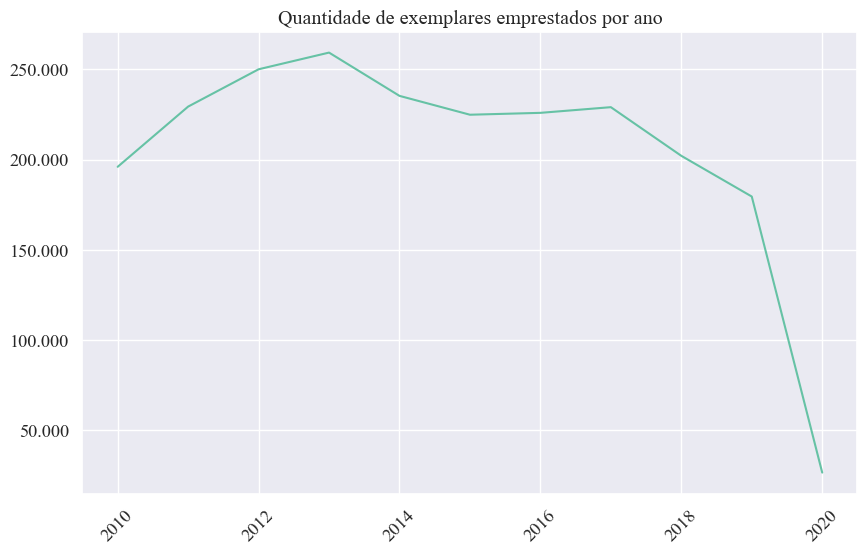

In [34]:
ax =  sns.lineplot(data=emprestimos_ano, x='Data', y='Quantidade')
ax.set(xlabel=None, ylabel=None)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
ax.set_title('Quantidade de exemplares emprestados por ano')


- Começou a decair o número de empréstimos a partir de 2013;
- Entre 2014 a 2016 ficou mais estável o quantitativo de empréstimo, entretanto em meados de 2017 já começou a decair novamente.
- 2019 foi o ano que mais decaiu;

Alguns apontamentos:

1. Os livros da biblioteca estão sendo atualizados?
2. Quantos alunos da universidade estão na modalidede de curso "Presencial" e qual o seu quantitativo?
    - Se houver mais alunos da modalidade "EAD", a partir de que ano esse quantitativo aumentou?
    (É interessante essa informação, pois se os empréstimos são apenas de livros físicos, somente os alunos que estão cursando presencialmente teriam uma facilidade maior para ter acesso à biblioteca. )


---

In [35]:
emprestimos_mes = emprestimos_data.groupby(by=emprestimos_data.Data.dt.month).size().reset_index(name='Quantidade')
emprestimos_mes.columns = ['Mês', 'Quantidade']
emprestimos_mes


,Mês,Quantidade
0,1,72060
1,2,226584
2,3,275305
3,4,229950
4,5,222839
5,6,151632
6,7,130608
7,8,252669
8,9,226785
9,10,206428


In [36]:
mes ={1: 'Jan',
      2: 'Fev',
      3: 'Mar',
      4: 'Abr',
      5: 'Mai',
      6: 'Jun',
      7: 'Jul',
      8: 'Ago',
      9: 'Set',
      10: 'Out',
      11: 'Nov',
      12: 'Dez'}

In [37]:
emprestimos_mes

,Mês,Quantidade
0,1,72060
1,2,226584
2,3,275305
3,4,229950
4,5,222839
5,6,151632
6,7,130608
7,8,252669
8,9,226785
9,10,206428


In [38]:
emprestimos_mes['Mês'] = emprestimos_mes['Mês'].map(mes)
emprestimos_mes

,Mês,Quantidade
0,Jan,72060
1,Fev,226584
2,Mar,275305
3,Abr,229950
4,Mai,222839
5,Jun,151632
6,Jul,130608
7,Ago,252669
8,Set,226785
9,Out,206428


### Gráfico - Exemplares emprestados por mês

Text(-0.5, 288000, 'Período de 2010 a 2020')

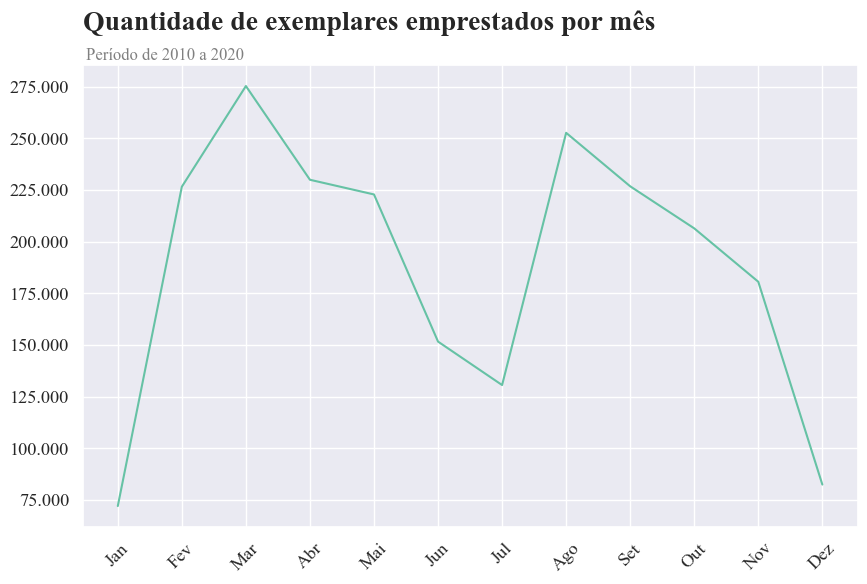

In [39]:
ax =  sns.lineplot(data=emprestimos_mes, x='Mês', y='Quantidade')
ax.set(xlabel=None, ylabel=None)
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
ax.set_title('Quantidade de exemplares emprestados por mês'+"\n",size=20,loc='left',weight='bold')
ax.text(s='Período de 2010 a 2020',x=-0.5,y=288000,fontsize=12, ha='left',color='gray')

- Podemos notar que Março e Agosto foram os meses que mais teve examplares emprestados;
- De Maio à Julho hove a primeira queda, que começou a crescer novamente em Agosto.
- Depois de Agosto, houve uma queda definitiva até o mês de dezembro.

Fazendo uma análise:

Faz sentido não ter tanto empréstimo nos meses de Junho e Julho, devido as férias que geralmente se passa em Julho. Por mais que em junho ainda tenha aula, muitas das vezes é o período das provas finais de semestre, então o motivo da decaída do empréstimo desse mês possa ser por conta disso.

Entretanto, os meses restantes cabe a direção averiguar o que deu certo em março e agosto, e também, analisar o que foi feito de diferente nos meses posteriores para checar o motivo da decaída.

Dezembro por ser fim de ano, pode ser que os alunos não façam o empréstimo pois a data para entrega do exemplar seja curta, devido ao recesso de fim de ano. Uma sugestão que pode ser feito pela direção é adotar políticas de entrega dos exemplares para depois do período de férias e recesso. 

---

In [40]:
emprestimos_hora = emprestimos_data.groupby(by=emprestimos_data.Data.dt.hour).size().reset_index(name='Quantidade')
emprestimos_hora.columns = ['Hora', 'Quantidade']
emprestimos_hora


,Hora,Quantidade
0,0,38
1,6,18
2,7,21609
3,8,112655
4,9,142339
5,10,199199
6,11,189034
7,12,155847
8,13,135349
9,14,162544


In [41]:
emprestimos_hora = emprestimos_hora.sort_values(ascending=True, by='Quantidade')

### Gráfico - Exemplares emprestados por hora

Text(-0.5, 242000, 'Período de 2010 a 2020')

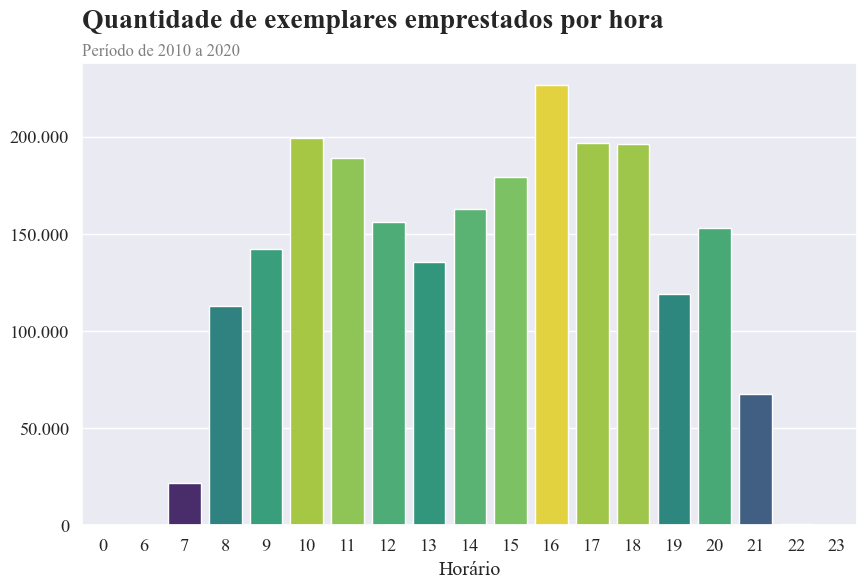

In [42]:
ax =  sns.barplot(data=emprestimos_hora, x='Hora', y='Quantidade', palette='viridis',
                  hue='Quantidade', dodge=False)
plt.legend([], [], frameon=False)
ax.set(xlabel='Horário', ylabel=None)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
ax.set_title('Quantidade de exemplares emprestados por hora'+"\n",size=20,loc='left',weight='bold')
ax.text(s='Período de 2010 a 2020',x=-0.5,y=242000,fontsize=12, ha='left',color='gray')

- Os horários de pico de atendimento são das 10h da manhã e ás 16h da tarde;
- Há baixa frequência na parte da manhã antes das 10h e a noite, depois das 18h.

---

### Variáveis Categóricas

In [43]:
emprestimos_biblioteca.columns

Index(['id_emprestimo', 'codigo_barras', 'data_renovacao', 'data_emprestimo',
       'data_devolucao', 'matricula_ou_siape', 'tipo_vinculo_usuario',
       'id_exemplar', 'colecao', 'biblioteca', 'status_material',
       'localizacao', 'CDU_geral'],
      dtype='str')

In [44]:
emprestimos_biblioteca['tipo_vinculo_usuario'].unique()

<ArrowStringArray>
[             'ALUNO DE GRADUAÇÃO',          'ALUNO DE PÓS-GRADUAÇÃO',
                         'DOCENTE', 'SERVIDOR TÉCNICO-ADMINISTRATIVO',
                 'DOCENTE EXTERNO',             'ALUNO MÉDIO/TÉCNICO',
                 'USUÁRIO EXTERNO',                          'OUTROS']
Length: 8, dtype: str

In [45]:
emprestimos_biblioteca['colecao'].unique()

<ArrowStringArray>
[                    'Acervo Circulante',
                                     nan,
                              'Folhetos',
                                 'Teses',
                          'Dissertações',
                           'Monografias',
          'Publicações de Autores do RN',
                   'Publicações da UFRN',
                            'Multimeios',
                   'Coleção Mossoroense',
                               'Eventos',
                    'Trabalho Acadêmico',
                   'Obras de Referência',
                           'Obras Raras',
                  'Literatura de Cordel',
                   'Coleção Zila Mamede',
 'Necessidades Educacionais Específicas']
Length: 17, dtype: str

In [46]:
emprestimos_biblioteca['biblioteca'].unique()

<ArrowStringArray>
[                                                          'Biblioteca Central Zila Mamede',
 'Biblioteca Setorial Prof. Rodolfo Helinski - Escola Agrícola de Jundiaí - EAJ  - Macaiba',
               'Biblioteca Setorial Bertha Cruz Enders - ­Escola de Saúde da UFRN - ESUFRN',
                                    'Biblioteca Setorial do Centro Ciências da Saúde - CCS',
                                                                                        nan,
          'Biblioteca Setorial Prof. Alberto Moreira Campos - ­Departamento de Odontologia',
                                'Biblioteca Setorial Prof. Ronaldo Xavier de Arruda - CCET',
                'Biblioteca Setorial do Centro de Ciências Humanas, Letras e Artes - CCHLA',
        'Biblioteca Setorial Prof. Horácio Nicolas Solimo - ­ Engenharia Química - EQ - CT',
           'Biblioteca Setorial Prof. Francisco Gurgel De Azevedo - Instituto Química - IQ',
                          'Biblioteca Setorial do C

In [47]:
emprestimos_biblioteca['CDU_geral'].unique()

<ArrowStringArray>
[            'Ciências aplicadas', 'Geografia. Biografia. História',
                      'Linguagem',               'Ciências sociais',
 'Matemática e ciências naturais',                       'Religião',
                  'Generalidades',         'Filosofia e psicologia',
                    'Belas artes']
Length: 9, dtype: str

In [48]:
def frequencia(variavel):
    
    dt = pd.DataFrame(emprestimos_biblioteca[variavel].value_counts())
    dt.columns = ['Quantidade']
    dt['Percentual'] = round((dt.Quantidade / dt.Quantidade.sum()) * 100, 2)
    return dt

### Distribuição dos empréstimos de exemplares pelos tipos de vínculo dos usuários

In [49]:
frequencia('tipo_vinculo_usuario')

,Quantidade,Percentual
tipo_vinculo_usuario,,
ALUNO DE GRADUAÇÃO,1771903,78.34
ALUNO DE PÓS-GRADUAÇÃO,320074,14.15
DOCENTE,78285,3.46
SERVIDOR TÉCNICO-ADMINISTRATIVO,34178,1.51
ALUNO MÉDIO/TÉCNICO,29986,1.33
DOCENTE EXTERNO,24606,1.09
USUÁRIO EXTERNO,2741,0.12
OUTROS,6,0.00


A maioria dos emprestimos dos exemplares são requisitados por alunos de graduação (78%).

Por eles serem os alunos que mais requisitam, é interessante investigar que tipo de exemplares para a biblioteca sempre manter eles abastecidos e atualizados.

### Coleções mais emprestadas

In [50]:
frequencia('colecao')

,Quantidade,Percentual
colecao,,
Acervo Circulante,2053120,99.06
Multimeios,7954,0.38
Monografias,4021,0.19
Dissertações,2406,0.12
Obras de Referência,1954,0.09
Publicações de Autores do RN,866,0.04
Publicações da UFRN,764,0.04
Teses,714,0.03
Folhetos,271,0.01


O que mais é requisitado são os acervos circulantes, livros e materiais que podem ser levados para casa por tempo determinado.
O restante são porcentagens muito abaixo dos 5%.

Para realizar um levantamento para conseguir que os alunos façam mais empréstimos, é interessante investigar se as demais coleções que não são tão requisitadas estão devidamente atualizadas, antes de tomar qualquer tipo de decisão eliminatória.

### Relação de empréstimos por biblioteca

In [51]:
frequencia('biblioteca')

,Quantidade,Percentual
biblioteca,,
Biblioteca Central Zila Mamede,1426122,68.81
Biblioteca Setorial do Centro Ciências da Saúde - CCS,118614,5.72
Biblioteca Setorial da Faculdade de Ciências da Saúde do Trairi - FACISA - Santa Cruz,77609,3.74
Biblioteca Setorial Prof. Alberto Moreira Campos - ­Departamento de Odontologia,66447,3.21
Biblioteca Setorial Profª. Maria Lúcia da Costa Bezerra - ­CERES­ - Caicó,61478,2.97
Biblioteca Setorial Bertha Cruz Enders - ­Escola de Saúde da UFRN - ESUFRN,46040,2.22
"Biblioteca Setorial do Centro de Ciências Humanas, Letras e Artes - CCHLA",40744,1.97
Biblioteca Setorial Dr. Paulo Bezerra - EMCM/RN - Caicó,32097,1.55
Biblioteca Setorial Profª. Maria José Mamede Galvão - FELCS - Currais Novos,29089,1.40


A Biblioteca Central Zila Mamede é a biblioteca que mais possui empréstimos, com um percentual de 51%.

Por outro lado, a Biblioteca Setorial de Engenharia Mecânica não possui um percentual de 0% de empréstimo, com uma quantidade de apenas 3 empréstimos registrados.

É necessário investigar com uma certa preocupação a biblioteca, pois pode ser que esteja com muitos materiais faltantes ou uma ausência do marketing.

Apenas com estas métricas não é possível afirmar com certeza a causa, pois também temos a questão do tamanho de cada biblioteca. Por a biblioteca central ser maior, faz sentido que ela possua um percentual maior, entretanto, pelo número baixíssimo de empréstimos da biblioteca de Engenharia Mecânica, o problema pode ser algo além de apenas o seu tamanho.

### Temas da CDU mais emprestados

In [52]:
frequencia('CDU_geral')

,Quantidade,Percentual
CDU_geral,,
Ciências aplicadas,1425473,63.02
Ciências sociais,369536,16.34
Geografia. Biografia. História,197246,8.72
Matemática e ciências naturais,68744,3.04
Generalidades,62521,2.76
Religião,62295,2.75
Filosofia e psicologia,60563,2.68
Belas artes,7911,0.35
Linguagem,7490,0.33


- Com 80.9%, os temas Geografia, Biografia e História estão entre os examplares mais emprestados;
- Abaixo, com 12%, temos o de Ciências aplicadas.

Os menos emprestados são:

- Linguagem;
- Belas Artes.

É interessante entender a causa do porquê Geografia, Biografia e História é tão procurado e Linguagem, Belas artes, não. 

Novamente, investigar se os conteúdos estão atualizados é o primeiro passo. Depois, é averiguar se os alunos tem o conhecimento da existências desses exemplares. Caso não, é trabalhar maneiras eficazes de marketing. 

---

### Distribuição de empréstimos mensais por ano

In [53]:
emprestimos_biblioteca.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,CDU_geral
0,709684,L095049,NaN,2010-01-04 07:44:10.721,2010/01/05 16:26:12.662000000,2008023265.0,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630.0,Ciências aplicadas
1,709685,L167050,NaN,2010-01-04 07:44:10.750,2010/01/12 07:34:13.934000000,2008023265.0,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647.0,Ciências aplicadas
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010-01-04 08:08:44.081,2010/02/25 07:36:25.800000000,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640.0,Ciências aplicadas
3,709687,L184117,2010/01/18 11:07:46.470000000,2010-01-04 08:24:21.284,2010/02/03 08:58:45.692000000,200721119.0,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609.0,Ciências aplicadas
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010-01-04 08:27:33.569,2010/02/03 13:06:30.662000000,2009045971.0,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686.0,Ciências aplicadas


Alunos da Graduação

In [54]:
emprestimos_biblioteca['tipo_vinculo_usuario'].value_counts()


tipo_vinculo_usuario
ALUNO DE GRADUAÇÃO                 1771903
ALUNO DE PÓS-GRADUAÇÃO              320074
DOCENTE                              78285
SERVIDOR TÉCNICO-ADMINISTRATIVO      34178
ALUNO MÉDIO/TÉCNICO                  29986
DOCENTE EXTERNO                      24606
USUÁRIO EXTERNO                       2741
OUTROS                                   6
Name: count, dtype: int64

In [55]:
alunos_graduacao = emprestimos_biblioteca[emprestimos_biblioteca['tipo_vinculo_usuario'] == 'ALUNO DE GRADUAÇÃO']
alunos_graduacao.colecao.value_counts()

colecao
Acervo Circulante                        1600155
Multimeios                                  4652
Monografias                                 3572
Dissertações                                1152
Obras de Referência                         1047
Publicações de Autores do RN                 595
Publicações da UFRN                          466
Teses                                        245
Folhetos                                     180
Trabalho Acadêmico                            81
Necessidades Educacionais Específicas         73
Eventos                                       57
Coleção Mossoroense                           17
Coleção Zila Mamede                           15
Literatura de Cordel                          11
Obras Raras                                    6
Name: count, dtype: int64

In [56]:
alunos_graduacao_acervo = alunos_graduacao.query('colecao == "Acervo Circulante"')

In [57]:
alunos_graduacao_acervo['data_emprestimo'].dt.year.value_counts().sort_index()

data_emprestimo
2010    124860
2011    157903
2012    177337
2013    185815
2014    170174
2015    162815
2016    163803
2017    165596
2018    145620
2019    127628
2020     18604
Name: count, dtype: int64

In [58]:
alunos_graduacao_acervo = pd.DataFrame(alunos_graduacao_acervo)
alunos_graduacao_acervo.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,CDU_geral
0,709684,L095049,NaN,2010-01-04 07:44:10.721,2010/01/05 16:26:12.662000000,2008023265.0,ALUNO DE GRADUAÇÃO,13259,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,630.0,Ciências aplicadas
1,709685,L167050,NaN,2010-01-04 07:44:10.750,2010/01/12 07:34:13.934000000,2008023265.0,ALUNO DE GRADUAÇÃO,70865,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,647.0,Ciências aplicadas
3,709687,L184117,2010/01/18 11:07:46.470000000,2010-01-04 08:24:21.284,2010/02/03 08:58:45.692000000,200721119.0,ALUNO DE GRADUAÇÃO,131639,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,609.0,Ciências aplicadas
4,709688,2007027500,2010/01/19 15:59:26.464000000,2010-01-04 08:27:33.569,2010/02/03 13:06:30.662000000,2009045971.0,ALUNO DE GRADUAÇÃO,225646,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,686.0,Ciências aplicadas
5,709689,L157395,2010/01/19 15:59:26.447000000,2010-01-04 08:27:33.596,2010/02/03 13:06:43.125000000,2009045971.0,ALUNO DE GRADUAÇÃO,57040,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,698.0,Ciências aplicadas


In [59]:
alunos_graduacao_acervo['data_emprestimo'] = pd.to_datetime(alunos_graduacao_acervo['data_emprestimo'])


In [60]:
alunos_graduacao_acervo['ano'] = alunos_graduacao_acervo['data_emprestimo'].dt.year
alunos_graduacao_acervo['mes'] = alunos_graduacao_acervo['data_emprestimo'].dt.month
alunos_graduacao_acervo = alunos_graduacao_acervo.loc[:,['ano','mes']]
alunos_graduacao_acervo = alunos_graduacao_acervo.value_counts().to_frame('quantidade').reset_index()
alunos_graduacao_acervo

,ano,mes,quantidade
0,2012,3,22797
1,2015,3,22483
2,2013,4,21853
3,2017,3,21735
4,2016,3,21692
...,...,...,...
118,2016,1,2670
119,2019,1,2276
120,2019,12,1980
121,2020,1,1781


---

In [61]:
def func_boxplot(dataset,x,y,titulo,subtitulo):
    
    sns.set_theme(context='notebook',
              style='darkgrid',
              palette='Set2',
              font_scale=1.2,
              font='Times New Roman',
              rc={'figure.figsize':(10,6)})
    
    ax = sns.boxplot(data=dataset, x=x, y=y, color='#DBA60D')
    ax.set(xlabel=None, ylabel=None)
    
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
    ax.set_title(titulo,size=20,loc='left',weight='bold')
    ax.text(s=subtitulo,x=-0.5,y=max(dataset[y])*1.05,fontsize=12, ha='left',color='gray')

### Gráfico - Empréstimos mensais realizados pelos alunos de graduação | Acervo Circulante

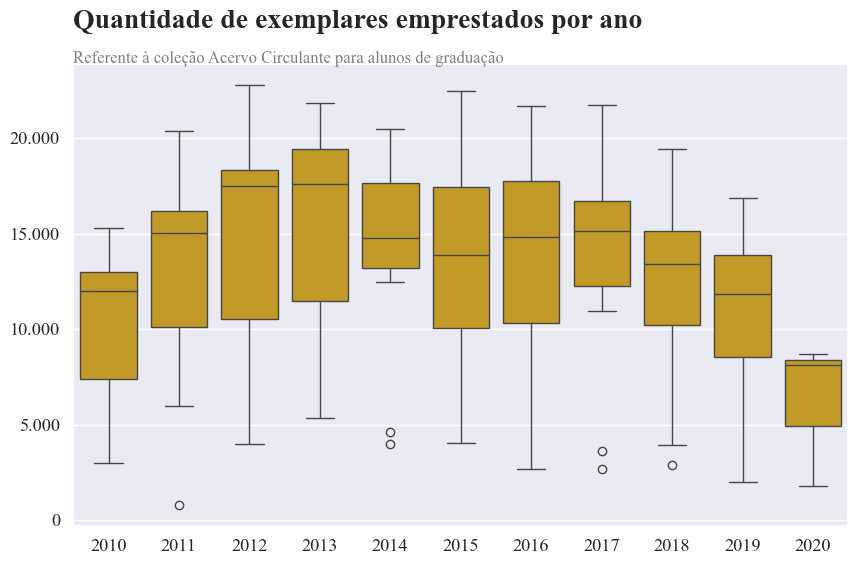

In [62]:
func_boxplot(alunos_graduacao_acervo,x='ano',y='quantidade',
             titulo='Quantidade de exemplares emprestados por ano'+"\n",subtitulo='Referente à coleção Acervo Circulante para alunos de graduação')

Ao analisar, podemos concluir que em 2014 começou um declínio de empréstimos. Após essa data, os exemplares emprestados permaneceu em um quantitativo mais baixo que os anos anteriores, mas se permaneceu "estável", até 2019 onde sofreu uma baixa maior.

Cabe a diretoria investigar o comportamento das bibliotecas nos anos de 2014 e 2019, para dimensionar o que foi feito nesses anos para resultar nesta baixa que impactou os anos posteriores negativamente.

---

Alunos Pós-Graduação

In [63]:
emprestimos_biblioteca.tipo_vinculo_usuario.value_counts()

tipo_vinculo_usuario
ALUNO DE GRADUAÇÃO                 1771903
ALUNO DE PÓS-GRADUAÇÃO              320074
DOCENTE                              78285
SERVIDOR TÉCNICO-ADMINISTRATIVO      34178
ALUNO MÉDIO/TÉCNICO                  29986
DOCENTE EXTERNO                      24606
USUÁRIO EXTERNO                       2741
OUTROS                                   6
Name: count, dtype: int64

In [64]:
alunos_pos_graduacao = emprestimos_biblioteca.query('tipo_vinculo_usuario == "ALUNO DE PÓS-GRADUAÇÃO"')
alunos_pos_graduacao.colecao.value_counts()

colecao
Acervo Circulante                        299201
Dissertações                                934
Obras de Referência                         700
Multimeios                                  559
Teses                                       367
Monografias                                 278
Publicações de Autores do RN                204
Publicações da UFRN                         121
Folhetos                                     60
Necessidades Educacionais Específicas        30
Eventos                                      26
Coleção Mossoroense                          23
Trabalho Acadêmico                           23
Coleção Zila Mamede                          11
Literatura de Cordel                          4
Name: count, dtype: int64

In [65]:
alunos_pos_acervo = alunos_pos_graduacao.query('colecao == "Acervo Circulante"')
alunos_pos_acervo = pd.DataFrame(alunos_pos_acervo)
alunos_pos_acervo.head()

,id_emprestimo,codigo_barras,data_renovacao,data_emprestimo,data_devolucao,matricula_ou_siape,tipo_vinculo_usuario,id_exemplar,colecao,biblioteca,status_material,localizacao,CDU_geral
2,709686,2006017618,2010/01/26 08:07:01.738000000,2010-01-04 08:08:44.081,2010/02/25 07:36:25.800000000,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO,195347,Acervo Circulante,Biblioteca Setorial Prof. Rodolfo Helinski - E...,REGULAR,640.0,Ciências aplicadas
25,709709,2009011815,2010/02/03 12:58:49.734000000,2010-01-04 10:02:59.828,2010/03/02 16:38:38.231000000,2008106583.0,ALUNO DE PÓS-GRADUAÇÃO,265828,Acervo Circulante,Biblioteca Setorial Prof. Alberto Moreira Camp...,REGULAR,620.0,Ciências aplicadas
29,709713,2008010513,NaN,2010-01-04 10:23:39.830,2010/01/05 11:57:06.156000000,2011101417.0,ALUNO DE PÓS-GRADUAÇÃO,190443,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,656.0,Ciências aplicadas
30,709714,2008046332,NaN,2010-01-04 10:23:39.859,2010/01/05 11:57:01.461000000,2011101417.0,ALUNO DE PÓS-GRADUAÇÃO,256856,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,619.0,Ciências aplicadas
43,709727,2007032237,NaN,2010-01-04 10:56:34.814,2010/01/28 11:12:34.011000000,2011113122.0,ALUNO DE PÓS-GRADUAÇÃO,228451,Acervo Circulante,Biblioteca Central Zila Mamede,REGULAR,692.0,Ciências aplicadas


In [66]:
alunos_pos_acervo['data_emprestimo'].value_counts()

data_emprestimo
2014-01-28 14:49:50.505    3
2018-11-22 18:28:01.619    3
2010-01-12 14:47:19.758    2
2010-01-13 16:37:54.455    2
2010-03-17 11:25:04.614    2
                          ..
2020-03-19 14:41:57.754    1
2020-03-19 14:42:56.670    1
2020-03-19 14:43:40.666    1
2020-06-09 11:54:02.669    1
2020-06-09 11:54:02.852    1
Name: count, Length: 298580, dtype: int64

In [67]:
alunos_pos_acervo['data_emprestimo'] = pd.to_datetime(alunos_pos_acervo['data_emprestimo'])

In [68]:
alunos_pos_acervo.data_emprestimo.value_counts()

data_emprestimo
2014-01-28 14:49:50.505    3
2018-11-22 18:28:01.619    3
2010-01-12 14:47:19.758    2
2010-01-13 16:37:54.455    2
2010-03-17 11:25:04.614    2
                          ..
2020-03-19 14:41:57.754    1
2020-03-19 14:42:56.670    1
2020-03-19 14:43:40.666    1
2020-06-09 11:54:02.669    1
2020-06-09 11:54:02.852    1
Name: count, Length: 298580, dtype: int64

In [69]:
alunos_pos_acervo['ano'] = alunos_pos_acervo['data_emprestimo'].dt.year
alunos_pos_acervo['mes'] = alunos_pos_acervo['data_emprestimo'].dt.month
alunos_pos_acervo = alunos_pos_acervo.loc[:,['ano','mes']]
alunos_pos_acervo = alunos_pos_acervo.value_counts().to_frame('quantidade').reset_index()
alunos_pos_acervo

,ano,mes,quantidade
0,2015,3,3927
1,2017,8,3837
2,2017,3,3722
3,2016,3,3711
4,2016,8,3662
...,...,...,...
119,2020,1,1143
120,2010,1,1105
121,2019,12,1069
122,2011,1,465


---

### Gráfico - Empréstimos Mensais realizados pelos alunos de Pós-Graducação | Acervo Circulante

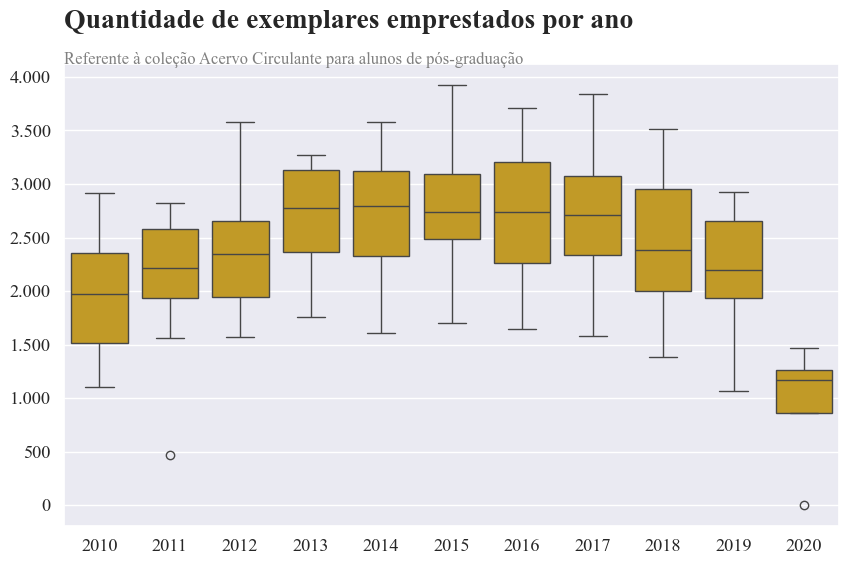

In [70]:
func_boxplot(alunos_pos_acervo,x='ano',y='quantidade',
             titulo='Quantidade de exemplares emprestados por ano'+"\n",subtitulo='Referente à coleção Acervo Circulante para alunos de pós-graduação')

Ao contrário do gráfico dos alunos de graduação, o declínio não começou entre 2013/2014.

Ao invés de decair em 2013, o quantitativo subiu. Os anos posteriores, a linha mediana ficou estável até 2017.

Em 2018 tivemos um declínio que decaiu mais ainda em 2020.

Com esta informação, podemos concluir que 2018 foi um ano de baixas no geral que cabe a direção investigar sua causa.

---

### Cálculo da quantidade de empréstimos realizados entre 2015 e 2020 por cada curso de graduação que passará pela avaliação.

Importando dados de usuário | API json

In [71]:
url_usuarios1 = 'https://raw.githubusercontent.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/main/Dia_6-Novos_dados_novas_analises/Datasets/cadastro_alunos.json?utm_medium=email&_hsenc=p2ANqtz--RVS1I2Zk5j5c-R7rZza3ApVQED0gBsBihm7oE2yJfqLObeXfdi32dfkppPfFI6Kbw55X4ZNHttYizwvj_ECxXcoP5lA&_hsmi=381427473&utm_content=381427473&utm_source=hs_automation'

In [72]:
response = requests.get(url_usuarios1)
response.status_code

200

In [73]:
dados_json = response.json()

In [74]:
if isinstance(dados_json, list):
    dados_logica = dados_json[0]
else:
    dados_logica = dados_json

In [75]:
lista = json.loads(dados_logica['registros'])

In [76]:
df_alunos1 = pd.DataFrame(lista)
df_alunos1

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,2009029003.0,ALUNO DE GRADUAÇÃO,FILOSOFIA
1,200617346.0,ALUNO DE GRADUAÇÃO,DIREITO
2,200746502.0,ALUNO DE GRADUAÇÃO,ENGENHARIA DE PETRÓLEO
3,200504968.0,ALUNO DE GRADUAÇÃO,ADMINISTRAÇÃO
4,200615572.0,ALUNO DE GRADUAÇÃO,CIÊNCIA DA COMPUTAÇÃO
...,...,...,...
62797,20200012706.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA
62798,20200039601.0,ALUNO DE GRADUAÇÃO,ENGENHARIA FLORESTAL
62799,20200132517.0,ALUNO DE GRADUAÇÃO,AGRONOMIA
62800,20200009344.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA


Importando dados de usuário | Excel

In [77]:
df_alunos2 = pd.read_excel(r'C:\Users\mgdin\OneDrive\Documentos\Projetos\Analise_Biblioteca\Dataframes\matricula_alunos.xlsx', skiprows=1)

In [78]:
df_alunos2.head()

,Número da matrícula,Tipo de vinculo,Curso
0,190001688.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
1,199014489.0,ALUNO DE GRADUAÇÃO,CIÊNCIAS BIOLÓGICAS
2,199735674.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
3,199812431.0,ALUNO DE GRADUAÇÃO,LETRAS
4,199823670.0,ALUNO DE GRADUAÇÃO,ECOLOGIA


Ajustando as tabelas

In [79]:
emprestimos_biblioteca.columns

Index(['id_emprestimo', 'codigo_barras', 'data_renovacao', 'data_emprestimo',
       'data_devolucao', 'matricula_ou_siape', 'tipo_vinculo_usuario',
       'id_exemplar', 'colecao', 'biblioteca', 'status_material',
       'localizacao', 'CDU_geral'],
      dtype='str')

In [80]:
df_alunos1.columns

Index(['matricula_ou_siape', 'tipo_vinculo_usuario', 'curso'], dtype='str')

In [81]:
df_alunos2 = df_alunos2.rename(columns={
    'Número da matrícula' : 'matricula_ou_siape',
    'Tipo de vinculo' : 'tipo_vinculo_usuario',
    'Curso' : 'curso'
})

In [82]:
df_alunos2.head()

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,190001688.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
1,199014489.0,ALUNO DE GRADUAÇÃO,CIÊNCIAS BIOLÓGICAS
2,199735674.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
3,199812431.0,ALUNO DE GRADUAÇÃO,LETRAS
4,199823670.0,ALUNO DE GRADUAÇÃO,ECOLOGIA


Concatenando as tabelas

In [83]:
alunos = pd.concat([df_alunos1, df_alunos2], ignore_index=True)
alunos.head()

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,2009029003.0,ALUNO DE GRADUAÇÃO,FILOSOFIA
1,200617346.0,ALUNO DE GRADUAÇÃO,DIREITO
2,200746502.0,ALUNO DE GRADUAÇÃO,ENGENHARIA DE PETRÓLEO
3,200504968.0,ALUNO DE GRADUAÇÃO,ADMINISTRAÇÃO
4,200615572.0,ALUNO DE GRADUAÇÃO,CIÊNCIA DA COMPUTAÇÃO


In [84]:
alunos['matricula_ou_siape'] = alunos['matricula_ou_siape'].astype(str)

Tabela de quantidade de empréstimos

In [85]:
alunos['curso'].value_counts()

curso
AGRONOMIA                                3324
MATEMÁTICA                               3246
CIÊNCIAS BIOLÓGICAS                      3211
COMUNICAÇÃO SOCIAL                       3211
BIBLIOTECONOMIA                          3186
CIÊNCIAS SOCIAIS                         3180
CIÊNCIA DA COMPUTAÇÃO                    3165
DANÇA                                    3152
SISTEMAS DE INFORMAÇÃO                   3152
ADMINISTRAÇÃO                            3123
DIREITO                                  3122
CIÊNCIAS E TECNOLOGIA                    2938
CIÊNCIAS ATUARIAIS                       2921
ENGENHARIA DE PETRÓLEO                   2908
FILOSOFIA                                2874
ENGENHARIA FLORESTAL                     2867
EDUCAÇÃO FÍSICA                          2867
ENFERMAGEM                               2855
PEDAGOGIA                                2847
ARQUITETURA E URBANISMO                  2837
BIOMEDICINA                              2806
ENGENHARIA CIVIL            

In [86]:
data_emprestimo = emprestimos_biblioteca.query("tipo_vinculo_usuario == 'ALUNO DE GRADUAÇÃO'")
data_emprestimo = data_emprestimo.loc[:,['matricula_ou_siape','data_emprestimo']]
data_emprestimo = data_emprestimo.reset_index(drop=True)
data_emprestimo

,matricula_ou_siape,data_emprestimo
0,2008023265.0,2010-01-04 07:44:10.721
1,2008023265.0,2010-01-04 07:44:10.750
2,200721119.0,2010-01-04 08:24:21.284
3,2009045971.0,2010-01-04 08:27:33.569
4,2009045971.0,2010-01-04 08:27:33.596
...,...,...
1771898,20190154579.0,2020-03-18 16:26:20.477
1771899,20160129109.0,2020-03-18 16:41:28.500
1771900,20160129109.0,2020-03-18 16:41:28.588
1771901,20160129109.0,2020-03-18 16:41:28.662


In [87]:
data_emprestimo['data_emprestimo'] = pd.to_datetime(data_emprestimo['data_emprestimo'], errors='coerce')
data_emprestimo['ano'] = data_emprestimo['data_emprestimo'].dt.year
data_emprestimo['ano']

0          2010
1          2010
2          2010
3          2010
4          2010
           ... 
1771898    2020
1771899    2020
1771900    2020
1771901    2020
1771902    2020
Name: ano, Length: 1771903, dtype: int32

In [88]:
data_emprestimo = data_emprestimo.query('ano >= 2015 & ano <= 2020')
data_emprestimo['ano']

943482     2015
943483     2015
943484     2015
943485     2015
943486     2015
           ... 
1771898    2020
1771899    2020
1771900    2020
1771901    2020
1771902    2020
Name: ano, Length: 828421, dtype: int32

In [89]:
data_emprestimo.isna().sum()

matricula_ou_siape    99
data_emprestimo        0
ano                    0
dtype: int64

In [90]:
data_emprestimo = data_emprestimo.dropna()

In [91]:
cadastro_cursos = alunos.query('curso ==  "BIBLIOTECONOMIA" | curso == "CIÊNCIAS SOCIAIS" | \
                                               curso == "COMUNICAÇÃO SOCIAL" | curso == "DIREITO" | curso == "FILOSOFIA" \
                                               | curso == "PEDAGOGIA"')
cadastro_cursos

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,2009029003.0,ALUNO DE GRADUAÇÃO,FILOSOFIA
1,200617346.0,ALUNO DE GRADUAÇÃO,DIREITO
5,200604856.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA
9,200711601.0,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
10,2008016110.0,ALUNO DE GRADUAÇÃO,PEDAGOGIA
...,...,...,...
70512,2009074564.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA
70516,2009074742.0,ALUNO DE GRADUAÇÃO,COMUNICAÇÃO SOCIAL
70519,2009075064.0,ALUNO DE GRADUAÇÃO,DIREITO
70523,2009075211.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA


Unindo tabela data com cadastro

In [92]:
emprestimos_curso = data_emprestimo.merge(cadastro_cursos)
emprestimos_curso

,matricula_ou_siape,data_emprestimo,ano,tipo_vinculo_usuario,curso
0,2014021454.0,2015-01-02 10:19:38.087,2015,ALUNO DE GRADUAÇÃO,FILOSOFIA
1,2013018187.0,2015-01-02 10:25:40.883,2015,ALUNO DE GRADUAÇÃO,DIREITO
2,2014029499.0,2015-01-02 12:26:43.571,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
3,2014029499.0,2015-01-02 12:26:43.840,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
4,2014029499.0,2015-01-02 12:26:44.750,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
...,...,...,...,...,...
223065,20200090284.0,2020-03-17 20:23:54.966,2020,ALUNO DE GRADUAÇÃO,DIREITO
223066,20180113385.0,2020-03-17 21:20:47.278,2020,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
223067,20190150079.0,2020-03-18 13:43:53.220,2020,ALUNO DE GRADUAÇÃO,PEDAGOGIA
223068,20190150079.0,2020-03-18 13:43:53.389,2020,ALUNO DE GRADUAÇÃO,PEDAGOGIA


In [93]:
emprestimos_curso = emprestimos_curso.drop(columns=['data_emprestimo'])
emprestimos_curso

,matricula_ou_siape,ano,tipo_vinculo_usuario,curso
0,2014021454.0,2015,ALUNO DE GRADUAÇÃO,FILOSOFIA
1,2013018187.0,2015,ALUNO DE GRADUAÇÃO,DIREITO
2,2014029499.0,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
3,2014029499.0,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
4,2014029499.0,2015,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
...,...,...,...,...
223065,20200090284.0,2020,ALUNO DE GRADUAÇÃO,DIREITO
223066,20180113385.0,2020,ALUNO DE GRADUAÇÃO,CIÊNCIAS SOCIAIS
223067,20190150079.0,2020,ALUNO DE GRADUAÇÃO,PEDAGOGIA
223068,20190150079.0,2020,ALUNO DE GRADUAÇÃO,PEDAGOGIA


In [94]:
emprestimos_cursos = emprestimos_curso.iloc[:,[1,3]].value_counts().reset_index()
emprestimos_cursos.columns = ['Ano','Curso','Quantidade_Emprestimo']
emprestimos_cursos

,Ano,Curso,Quantidade_Emprestimo
0,2017,COMUNICAÇÃO SOCIAL,8761
1,2016,COMUNICAÇÃO SOCIAL,8488
2,2017,DIREITO,8171
3,2015,BIBLIOTECONOMIA,7989
4,2016,FILOSOFIA,7951
5,2017,PEDAGOGIA,7888
6,2015,DIREITO,7866
7,2015,CIÊNCIAS SOCIAIS,7783
8,2017,FILOSOFIA,7776
9,2017,BIBLIOTECONOMIA,7661


Formação da tabela

In [95]:
emprestimos_cursos_especificos = emprestimos_cursos.pivot_table(
    index = 'Curso',
    columns = 'Ano',
    values =  'Quantidade_Emprestimo',
    fill_value = '-',
    aggfunc = sum,
    margins = True,
    margins_name = "Total Emprestimo",
)

emprestimos_cursos_especificos

Ano,2015,2016,2017,2018,2019,2020,Total Emprestimo
Curso,,,,,,,
BIBLIOTECONOMIA,7989,7319,7661,6661,6264,945,36839
CIÊNCIAS SOCIAIS,7783,7294,7269,6472,6061,860,35739
COMUNICAÇÃO SOCIAL,7548,8488,8761,7336,6210,836,39179
DIREITO,7866,7599,8171,7249,6119,937,37941
FILOSOFIA,7362,7951,7776,6623,5872,865,36449
PEDAGOGIA,7579,7545,7888,6809,6186,916,36923
Total Emprestimo,46127,46196,47526,41150,36712,5359,223070


---

### Diferença percentual de empréstimos realizados nos últimos anos (2017, 2018, 2019) para cada curso. | Alunos Pós-Graduação


Importando o cadastro de alunos | Excel

In [96]:
cadastro_2010 = pd.read_excel('https://github.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/raw/main/Dia_6-Novos_dados_novas_analises/Datasets/matricula_alunos.xlsx',
                                        sheet_name='Até 2010',skiprows=1)

cadastro_apos_2010 = pd.read_excel('https://github.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/raw/main/Dia_6-Novos_dados_novas_analises/Datasets/matricula_alunos.xlsx',
                                        sheet_name='Após 2010',skiprows=1)

In [97]:
cadastro_2010 = pd.DataFrame(cadastro_2010)
cadastro_apos_2010 = pd.DataFrame(cadastro_apos_2010)
cadastro_apos_2010

,Matricula,Tipo de vinculo,Cursos
0,2.010000e+09,ALUNO DE GRADUAÇÃO,DIREITO
1,2.010000e+09,ALUNO DE GRADUAÇÃO,AGRONOMIA
2,2.010001e+09,ALUNO DE GRADUAÇÃO,ENGENHARIA QUÍMICA
3,2.010003e+09,ALUNO DE GRADUAÇÃO,ENGENHARIA AMBIENTAL
4,2.010003e+09,ALUNO DE GRADUAÇÃO,GEOGRAFIA
...,...,...,...
2269,2.015012e+10,ALUNO DE GRADUAÇÃO,LETRAS
2270,2.015075e+09,ALUNO DE GRADUAÇÃO,DANÇA
2271,2.016000e+10,ALUNO DE GRADUAÇÃO,ENGENHARIA DA COMPUTAÇÃO
2272,2.017009e+10,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA


In [98]:
cadastro_apos_2010.columns = ['matricula_ou_siape','tipo_vinculo_usuario','curso']
cadastro_2010.columns = ['matricula_ou_siape','tipo_vinculo_usuario','curso']

cadastro_2010

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,1.900017e+08,ALUNO DE GRADUAÇÃO,MATEMÁTICA
1,1.990145e+08,ALUNO DE GRADUAÇÃO,CIÊNCIAS BIOLÓGICAS
2,1.997357e+08,ALUNO DE GRADUAÇÃO,MATEMÁTICA
3,1.998124e+08,ALUNO DE GRADUAÇÃO,LETRAS
4,1.998237e+08,ALUNO DE GRADUAÇÃO,ECOLOGIA
...,...,...,...
7721,2.009075e+09,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA
7722,2.009075e+09,ALUNO DE GRADUAÇÃO,ANÁLISE E DESENVOLVIMENTO DE SISTEMAS
7723,2.009075e+09,ALUNO DE GRADUAÇÃO,ADMINISTRAÇÃO
7724,2.009075e+09,ALUNO DE GRADUAÇÃO,MÚSICA


In [99]:
cadastro_2010.tipo_vinculo_usuario.value_counts()

tipo_vinculo_usuario
ALUNO DE GRADUAÇÃO    7726
Name: count, dtype: int64

In [100]:
cadastro_excel = pd.concat([cadastro_2010,cadastro_apos_2010],ignore_index=True)
cadastro_excel['matricula_ou_siape'] = cadastro_excel['matricula_ou_siape'].astype('string')

cadastro_excel

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,190001688.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
1,199014489.0,ALUNO DE GRADUAÇÃO,CIÊNCIAS BIOLÓGICAS
2,199735674.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
3,199812431.0,ALUNO DE GRADUAÇÃO,LETRAS
4,199823670.0,ALUNO DE GRADUAÇÃO,ECOLOGIA
...,...,...,...
9995,20150116770.0,ALUNO DE GRADUAÇÃO,LETRAS
9996,2015074523.0,ALUNO DE GRADUAÇÃO,DANÇA
9997,20160002745.0,ALUNO DE GRADUAÇÃO,ENGENHARIA DA COMPUTAÇÃO
9998,20170086533.0,ALUNO DE GRADUAÇÃO,BIBLIOTECONOMIA


Importando cadastro de alunos | .json

In [114]:
url_cadastro = 'https://github.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/raw/main/Dia_6-Novos_dados_novas_analises/Datasets/cadastro_alunos.json'

In [122]:
cadastro_json = pd.read_json(url_cadastro)
cadastro_json.head()

,tipo_curso,registros
0,GRADUACAO,"[{""matricula_ou_siape"": ""2009029003.0"", ""tipo_..."
1,POSGRADUACAO,"[{""matricula_ou_siape"": ""2008112114.0"", ""tipo_..."


In [126]:
cadastro_json_pos = json.loads(cadastro_json['registros'][1])
cadastro_json_pos = pd.DataFrame(cadastro_json_pos)
cadastro_json_pos.head()


,matricula_ou_siape,tipo_vinculo_usuario,curso
0,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO,CIÊNCIAS ODONTOLÓGICAS
1,2008106583.0,ALUNO DE PÓS-GRADUAÇÃO,ENGENHARIA DE SOFTWARE
2,2011101417.0,ALUNO DE PÓS-GRADUAÇÃO,ARQUITETURA E URBANISMO
3,2011113122.0,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
4,2010110903.0,ALUNO DE PÓS-GRADUAÇÃO,ARTES CÊNICAS


In [128]:
cadastro_json_pos.tipo_vinculo_usuario.value_counts()

tipo_vinculo_usuario
ALUNO DE PÓS-GRADUAÇÃO    19440
Name: count, dtype: int64

In [108]:
cadastro_json['matricula_ou_siape'] = cadastro_json['matricula_ou_siape'].astype('string')

Concatenando as tabelas

In [129]:
cadastro_alunos_pos = pd.concat([cadastro_excel,cadastro_json_pos], ignore_index=True)
cadastro_alunos_pos

,matricula_ou_siape,tipo_vinculo_usuario,curso
0,190001688.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
1,199014489.0,ALUNO DE GRADUAÇÃO,CIÊNCIAS BIOLÓGICAS
2,199735674.0,ALUNO DE GRADUAÇÃO,MATEMÁTICA
3,199812431.0,ALUNO DE GRADUAÇÃO,LETRAS
4,199823670.0,ALUNO DE GRADUAÇÃO,ECOLOGIA
...,...,...,...
29435,20201013501.0,ALUNO DE PÓS-GRADUAÇÃO,GESTÃO DA INFORMAÇÃO E DO CONHECIMENTO
29436,20201014062.0,ALUNO DE PÓS-GRADUAÇÃO,"CIÊNCIA, TECNOLOGIA E INOVAÇÃO"
29437,20201017690.0,ALUNO DE PÓS-GRADUAÇÃO,CIÊNCIAS DA SAÚDE
29438,20201014465.0,ALUNO DE PÓS-GRADUAÇÃO,DESIGN


In [130]:
cadastro_alunos_pos['tipo_vinculo_usuario'].value_counts()

tipo_vinculo_usuario
ALUNO DE PÓS-GRADUAÇÃO    19440
ALUNO DE GRADUAÇÃO        10000
Name: count, dtype: int64

In [131]:
cadastro_alunos_pos = cadastro_alunos_pos.query('tipo_vinculo_usuario =="ALUNO DE PÓS-GRADUAÇÃO"')
cadastro_alunos_pos.head()

,matricula_ou_siape,tipo_vinculo_usuario,curso
10000,2008112114.0,ALUNO DE PÓS-GRADUAÇÃO,CIÊNCIAS ODONTOLÓGICAS
10001,2008106583.0,ALUNO DE PÓS-GRADUAÇÃO,ENGENHARIA DE SOFTWARE
10002,2011101417.0,ALUNO DE PÓS-GRADUAÇÃO,ARQUITETURA E URBANISMO
10003,2011113122.0,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
10004,2010110903.0,ALUNO DE PÓS-GRADUAÇÃO,ARTES CÊNICAS


Filtrando datas de empréstimo solicitadas

In [132]:
data_emprestimo_pos = emprestimos_biblioteca.loc[:,['matricula_ou_siape','data_emprestimo']]
data_emprestimo_pos = data_emprestimo_pos.query('data_emprestimo > 2017')
data_emprestimo_pos = data_emprestimo_pos.reset_index(drop=True)
data_emprestimo_pos

,matricula_ou_siape,data_emprestimo
0,2014035816.0,2017-01-02 08:01:14.113
1,20161011168.0,2017-01-02 08:29:46.657
2,20161011168.0,2017-01-02 08:29:46.722
3,20161011168.0,2017-01-02 08:29:46.794
4,20161010760.0,2017-01-02 08:38:40.009
...,...,...
638799,3067431.0,2020-05-05 19:51:06.059
638800,3067431.0,2020-05-05 19:51:06.135
638801,3067431.0,2020-05-05 19:51:06.164
638802,20201014993.0,2020-06-09 11:54:02.669


In [156]:
emprestimos_alunos_pos_partir_2017 = data_emprestimo_pos.merge(cadastro_alunos_pos)
emprestimos_alunos_pos_partir_2017

,matricula_ou_siape,data_emprestimo,tipo_vinculo_usuario,curso
0,20161011168.0,2017-01-02 08:29:46.657,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
1,20161011168.0,2017-01-02 08:29:46.722,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
2,20161011168.0,2017-01-02 08:29:46.794,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
3,20161010760.0,2017-01-02 08:38:40.009,ALUNO DE PÓS-GRADUAÇÃO,BIOINFORMÁTICA
4,20161011168.0,2017-01-02 08:46:42.991,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
...,...,...,...,...
95571,20191017055.0,2020-03-19 14:41:57.754,ALUNO DE PÓS-GRADUAÇÃO,ENGENHARIA CIVIL
95572,20191017055.0,2020-03-19 14:42:56.670,ALUNO DE PÓS-GRADUAÇÃO,ENGENHARIA CIVIL
95573,20191017055.0,2020-03-19 14:43:40.666,ALUNO DE PÓS-GRADUAÇÃO,ENGENHARIA CIVIL
95574,20201014993.0,2020-06-09 11:54:02.669,ALUNO DE PÓS-GRADUAÇÃO,DESIGN


In [157]:
emprestimos_alunos_pos_partir_2017['data_emprestimo'] = pd.to_datetime(emprestimos_alunos_pos_partir_2017['data_emprestimo'], errors='coerce')

In [158]:
emprestimos_alunos_pos_partir_2017.head()

,matricula_ou_siape,data_emprestimo,tipo_vinculo_usuario,curso
0,20161011168.0,2017-01-02 08:29:46.657,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
1,20161011168.0,2017-01-02 08:29:46.722,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
2,20161011168.0,2017-01-02 08:29:46.794,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
3,20161010760.0,2017-01-02 08:38:40.009,ALUNO DE PÓS-GRADUAÇÃO,BIOINFORMÁTICA
4,20161011168.0,2017-01-02 08:46:42.991,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA


In [159]:
emprestimos_alunos_pos_partir_2017['data_emprestimo'] = emprestimos_alunos_pos_partir_2017['data_emprestimo'].dt.year
emprestimos_alunos_pos_partir_2017.head()

,matricula_ou_siape,data_emprestimo,tipo_vinculo_usuario,curso
0,20161011168.0,2017,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
1,20161011168.0,2017,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
2,20161011168.0,2017,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA
3,20161010760.0,2017,ALUNO DE PÓS-GRADUAÇÃO,BIOINFORMÁTICA
4,20161011168.0,2017,ALUNO DE PÓS-GRADUAÇÃO,FILOSOFIA


In [161]:
emprestimos_alunos_pos_partir_2017 = emprestimos_alunos_pos_partir_2017.iloc[:,[1,3]].value_counts().reset_index()
emprestimos_alunos_pos_partir_2017.columns = ['Ano','Curso', 'Quantidade_Emprestimo']
emprestimos_alunos_pos_partir_2017.head()

,Ano,Curso,Quantidade_Emprestimo
0,2017,ADMINISTRAÇÃO,2651
1,2018,CIÊNCIAS ODONTOLÓGICAS,2612
2,2017,ENGENHARIA DE SOFTWARE,2539
3,2017,CIÊNCIAS DA SAÚDE,2524
4,2017,"CIÊNCIA, TECNOLOGIA E INOVAÇÃO",2520


In [162]:
emprestimos_pos_curso = emprestimos_alunos_pos_partir_2017.pivot_table(
    index = 'Curso',
    columns = 'Ano',
    values =  'Quantidade_Emprestimo',
)

emprestimos_pos_curso

Ano,2017,2018,2019,2020
Curso,,,,
ADMINISTRAÇÃO,2651.0,2388.0,1746.0,274.0
ARQUITETURA E URBANISMO,2295.0,1995.0,1867.0,263.0
ARTES CÊNICAS,2217.0,2162.0,1895.0,239.0
BIOINFORMÁTICA,2308.0,1990.0,1889.0,272.0
BIOQUÍMICA,2389.0,2021.0,2126.0,283.0
CIÊNCIA E ENGENHARIA DE MATERIAIS,2404.0,2227.0,2100.0,336.0
"CIÊNCIA, TECNOLOGIA E INOVAÇÃO",2520.0,2451.0,2101.0,314.0
CIÊNCIAS DA SAÚDE,2524.0,2060.0,1874.0,239.0
CIÊNCIAS ODONTOLÓGICAS,2488.0,2612.0,2201.0,361.0


---

Import de dados da previsão de 2022

In [170]:
previsao_2022 = pd.read_table('https://github.com/FranciscoFoz/7_Days_of_Code_Alura-Python-Pandas/raw/main/Dia_7-Apresentando_resultados_em_HTML/Dataset/previsao')
previsao_2022.head()

,curso previsao_2022
0,administracao 1905
1,arquitetura_e_urbanismo 1896
2,artes_cenicas 1920
3,bioinformatica 2302
4,bioquimica 2090


In [171]:
previsao_2022 = previsao_2022['curso previsao_2022'].str.split(' ', expand=True)
previsao_2022.head()

,0,1
0,administracao,1905
1,arquitetura_e_urbanismo,1896
2,artes_cenicas,1920
3,bioinformatica,2302
4,bioquimica,2090


Concatenando com a tabela anterior

In [175]:
previsao_2022.index = emprestimos_pos_curso.index
emprestimos_pos_curso['2022'] = previsao_2022.iloc[:,1]
emprestimos_pos_curso

Ano,2017,2018,2019,2020,2022
Curso,,,,,
ADMINISTRAÇÃO,2651.0,2388.0,1746.0,274.0,1905
ARQUITETURA E URBANISMO,2295.0,1995.0,1867.0,263.0,1896
ARTES CÊNICAS,2217.0,2162.0,1895.0,239.0,1920
BIOINFORMÁTICA,2308.0,1990.0,1889.0,272.0,2302
BIOQUÍMICA,2389.0,2021.0,2126.0,283.0,2090
CIÊNCIA E ENGENHARIA DE MATERIAIS,2404.0,2227.0,2100.0,336.0,2010
"CIÊNCIA, TECNOLOGIA E INOVAÇÃO",2520.0,2451.0,2101.0,314.0,1960
CIÊNCIAS DA SAÚDE,2524.0,2060.0,1874.0,239.0,1730
CIÊNCIAS ODONTOLÓGICAS,2488.0,2612.0,2201.0,361.0,2405


In [193]:
emprestimos_pos_curso['2022'] = emprestimos_pos_curso['2022'].astype(int)

Função para percentual

In [194]:
def percentual_ano_anterior(linha,ano_inicial,ano_final):
    variacao_inicial = linha[ano_inicial]
    variacao_final = linha[ano_final]
    if variacao_inicial == 0:
        return None
    variacao = ((variacao_final - variacao_inicial) / variacao_inicial) * 100
    return round(variacao,2)
    

In [195]:
emprestimos_pos_curso.head()

Ano,2017,2018,2019,2020,2022
Curso,,,,,
ADMINISTRAÇÃO,2651.0,2388.0,1746.0,274.0,1905
ARQUITETURA E URBANISMO,2295.0,1995.0,1867.0,263.0,1896
ARTES CÊNICAS,2217.0,2162.0,1895.0,239.0,1920
BIOINFORMÁTICA,2308.0,1990.0,1889.0,272.0,2302
BIOQUÍMICA,2389.0,2021.0,2126.0,283.0,2090


In [196]:
emprestimos_pos_curso.columns

Index([2017, 2018, 2019, 2020, '2022'], dtype='object', name='Ano')

In [197]:
percentual_emprestimo = pd.DataFrame({
    'Percentual_2017-2018' : emprestimos_pos_curso.apply(lambda linha: percentual_ano_anterior(linha, 2017, 2018), axis=1),
    'Percentual_2018-2019' : emprestimos_pos_curso.apply(lambda linha: percentual_ano_anterior(linha, 2018, 2019), axis=1),
    'Percentual_2019-2022' : emprestimos_pos_curso.apply(lambda linha: percentual_ano_anterior(linha, 2019, '2022'), axis=1)
})

In [198]:
percentual_emprestimo

,Percentual_2017-2018,Percentual_2018-2019,Percentual_2019-2022
Curso,,,
ADMINISTRAÇÃO,-9.92,-26.88,9.11
ARQUITETURA E URBANISMO,-13.07,-6.42,1.55
ARTES CÊNICAS,-2.48,-12.35,1.32
BIOINFORMÁTICA,-13.78,-5.08,21.86
BIOQUÍMICA,-15.40,5.20,-1.69
CIÊNCIA E ENGENHARIA DE MATERIAIS,-7.36,-5.70,-4.29
"CIÊNCIA, TECNOLOGIA E INOVAÇÃO",-2.74,-14.28,-6.71
CIÊNCIAS DA SAÚDE,-18.38,-9.03,-7.68
CIÊNCIAS ODONTOLÓGICAS,4.98,-15.74,9.27


Formatação da tabela

In [199]:
percentual_emprestimo.reset_index(inplace=True)
percentual_emprestimo.columns = percentual_emprestimo.columns.str.capitalize()
percentual_emprestimo.Curso = percentual_emprestimo.Curso.str.capitalize()
percentual_emprestimo

,Curso,Percentual_2017-2018,Percentual_2018-2019,Percentual_2019-2022
0,Administração,-9.92,-26.88,9.11
1,Arquitetura e urbanismo,-13.07,-6.42,1.55
2,Artes cênicas,-2.48,-12.35,1.32
3,Bioinformática,-13.78,-5.08,21.86
4,Bioquímica,-15.40,5.20,-1.69
5,Ciência e engenharia de materiais,-7.36,-5.70,-4.29
6,"Ciência, tecnologia e inovação",-2.74,-14.28,-6.71
7,Ciências da saúde,-18.38,-9.03,-7.68
8,Ciências odontológicas,4.98,-15.74,9.27
9,Design,-19.65,0.58,-0.89


Estrutura da tabela em HTML

In [200]:

th_props = [
  ('font-size', '1.4rem'),
  ('text-align', 'center'),
  ('font-weight', 'bold'),
  ('color', 'whitesmoke'),
  ('background-color', '#DE8B21'),
  ('border-radius', '0.25rem'),
  ('box-shadow','0 0 1rem gray')
  ]

td_props = [
  ('font-size', '1rem'),
  ('padding','0.5rem'),
  ('text-align', 'left'),
  ('font-weight', 'bold'),
  ('border-bottom','0.1rem solid lightgray')
  ]

styles = [
  dict(selector="th", props=th_props),
  dict(selector="td", props=td_props)
  ]


In [203]:
percentual_emprestimo.style.text_gradient(
    cmap='Reds',
    low=0.2,
    axis=1,
    vmax=0.1,
    vmin=0).format('{:.2f}%',subset=['Percentual_2017-2018','Percentual_2018-2019','Percentual_2019-2022']) \
           .hide(axis="index")\
           .set_table_styles(styles) \
           .to_html('percentual_emprestimo.html', doctype_html=True, table_attributes='style="border-collapse: collapse; width: 100%; border: 0.1rem solid lightgray;"')    
